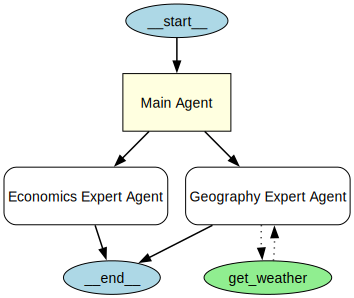

In [10]:
from ssl import SO_TYPE
from agents import Agent, Runner, SQLiteSession, function_tool, trace
from agents.extensions.visualization import draw_graph
from pydantic import BaseModel

session = SQLiteSession("user_111111", "ai-memory.db")

class Answer(BaseModel):
    answer: str 
    background_explanation : str 


@function_tool
def get_weather():
    return "30"

geography_agent = Agent(
    name="Geography Expert Agent",
    instructions="""
    You are a expert in geography, you answer questions related to them. 
    Reply with minimum tokens.
    - Short words only
    - No filler phrases (e.g. "Great question!", "Certainly!", "Of course!")
    - No repetition of the question
    - Answer only what is asked
    - Skip pleasantries""",
    handoff_description="Use this to answer geography related questions.",
    tools=[get_weather],
    output_type=Answer
)

economics_agent = Agent(
    name="Economics Expert Agent",
    instructions="""
    You are aw expert in economics, you answer questions related to them. 
    Reply with minimum tokens.
    - Short words only
    - No filler phrases (e.g. "Great question!", "Certainly!", "Of course!")
    - No repetition of the question
    - Answer only what is asked
    - Skip pleasantries""",
    handoff_description="Use this to answer economics questions.",
)

main_agent = Agent(
    name="Main Agent",
    instructions="""You are a routing agent. 
You MUST transfer to the appropriate specialist agent.
- Geography questions → Geography Expert Agent
- Economics questions → Economics Expert Agent
Never answer directly. Always handoff.""",
    handoffs=[
        economics_agent,
        geography_agent,
    ]
)

draw_graph(main_agent)

In [11]:
with trace("user_111111"):
    result = await Runner.run(
        main_agent,
        "What is the capital of Colombia's northen province?",
        session = session,
    )
    result = await Runner.run(
        main_agent,
        "What is the capital of Cambodia's northen province?",
        session = session,
    )
    result = await Runner.run(
        main_agent,
        "What is the capital of Japan's northen province?",
        session = session,
    )